In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy
from scipy.integrate import quad
import pandas as pd
from scipy import signal
from scipy.integrate import simpson

Definimos y calculamos todos los datos importantes para comenzar la tarea

In [ ]:
#Datos iniciales
g = 9.81 #[m/s2]
gamma = 3.3
H_rms = 3.5 #[m] (altura media cuadrática)
T_p = 15 #[s] (periodo peak)
f_p = 1/T_p #[1/s] (frecuencia peak)
D = 1500 #[s] (duración de muestreo)
f_s = 10 #[1/s] (frecuencia muestreo)
delta_f = 1/D #[1/s] (delta frecuencia)
f_nyquist = f_s/2 #[1/s] (frecuencia Nyquist)
delta_t = 1/f_s #[s] (delta tiempo)

Lo primero que hacemos es transformar la altura media cuadrática a la altura significativa, esto lo hacemos con la propoción que no entrega la distribución de raylight.



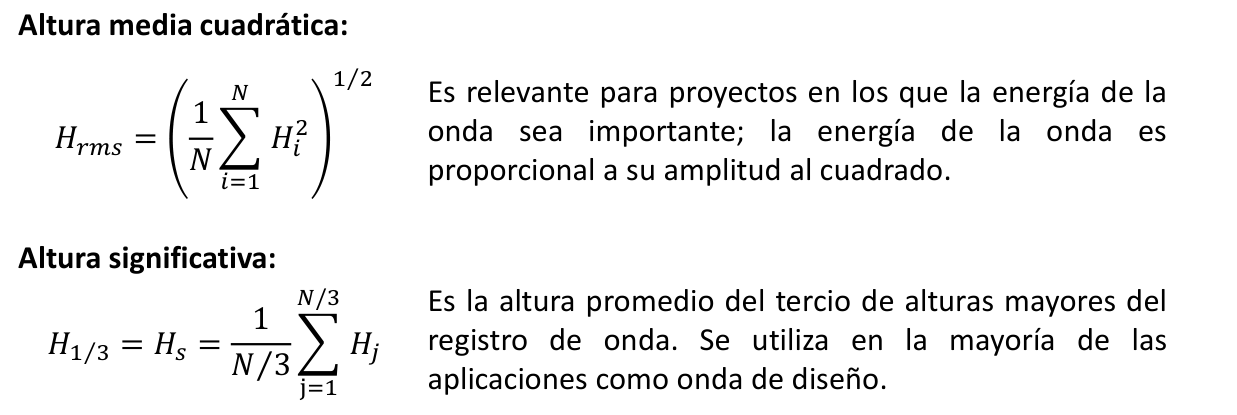

Luego tipear la fórmula del espectro JONSWAP tenemos que obtener la valor de la varianza para cada frecuencia, pero nos falta solo una constante: alpha. Alpha es el que considera la altura significativa y controla que tan achatada será la distribución, por lo tanto tenemos que encontrar su valor, que será proporcional al H_s que obtuvimos en el paso anterior. Para ello integramos espectro Jonswap con alpha = 1 (Aunque lo que hicimos fue sacar alpha de la integral para obtener su valor) desde 0 hasta el infinito para obtener el momento de orden 0. La raiz del momento de orden 0 por 4 debe ser proporcional a H_s. Por lo tanto haciendo la igualdad podemos obtener el valor real de alpha que usaremos en los siguientes pasos:

$A_{S_f} = \int_{0}^{\infty} S_{f}(f; f_p, \alpha=1) \,df$

$m_0 = \frac{H_s^2}{16}$

$\alpha = \frac{m_0}{A_{S_f}}$

In [ ]:
def espectro_jonswap(f, f_p, alpha):
    sigma = np.where(f < f_p, 0.07, 0.09)
    exponente_gamma = np.exp(-((f - f_p)**2) / (2 * sigma**2 * f_p**2))
    factor_realce = gamma**exponente_gamma
    espectro_pm = (alpha * g**2) / ((2 * np.pi)**4 * f**5) * np.exp(-(5/4) * (f_p / f)**4)
    S_f = espectro_pm * factor_realce

    return S_f

H_promedio = H_rms/1.13

area_s_f = quad(espectro_jonswap, 0, np.inf, args=(f_p, 1))
print(area_s_f[0])



H_s = 1.6*H_promedio #(altura significativa)
print(H_s)
m_o = (H_s**2)/16
print(m_o)
alpha = m_o/area_s_f[0]
print(alpha)

953.386024818715
4.955752212389381
1.5349674994126403
0.0016100167817170513


Ahora definimos la formula de amplitud, para cada valor de varianza y el delta de frecuencia que habiamos definido antes.

$a_i = \sqrt{2 \cdot S(f_i) \cdot \Delta f}$

Creamos un array desde aprox 0 (para que no se invalide la función) hasta la frecuencia de nyquist con paso delta_f. Limitarlo en la frecuencia de nyquist será útil en la 2da parte de la tarea cuando haya que ensamblar el espectro con la transformada de fourier y no se produzca aliasing.

Resolvemos el array de frecuencias para obtener un array de amplitud.

Creamos el array tiempo desde casi 0 hasta la duración del muestreo, con paso delta t, que equivale intervalo de tiempo entre dos puntos sucesivos debido a la frecuencia de muestreo f_s.

Creamos el gráfico del espectro para viasualizar que todo se haya calculado bien.

0.0006666666666666666
5.0
[1.00000000e-15 6.66666667e-04 1.33333333e-03 ... 4.99866667e+00
 4.99933333e+00 5.00000000e+00]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 3.18550317e-08
 3.18337979e-08 3.18125810e-08]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 6.51716009e-06
 6.51498763e-06 6.51281618e-06]
[1.0000e-15 1.0000e-01 2.0000e-01 ... 1.4998e+03 1.4999e+03 1.5000e+03]


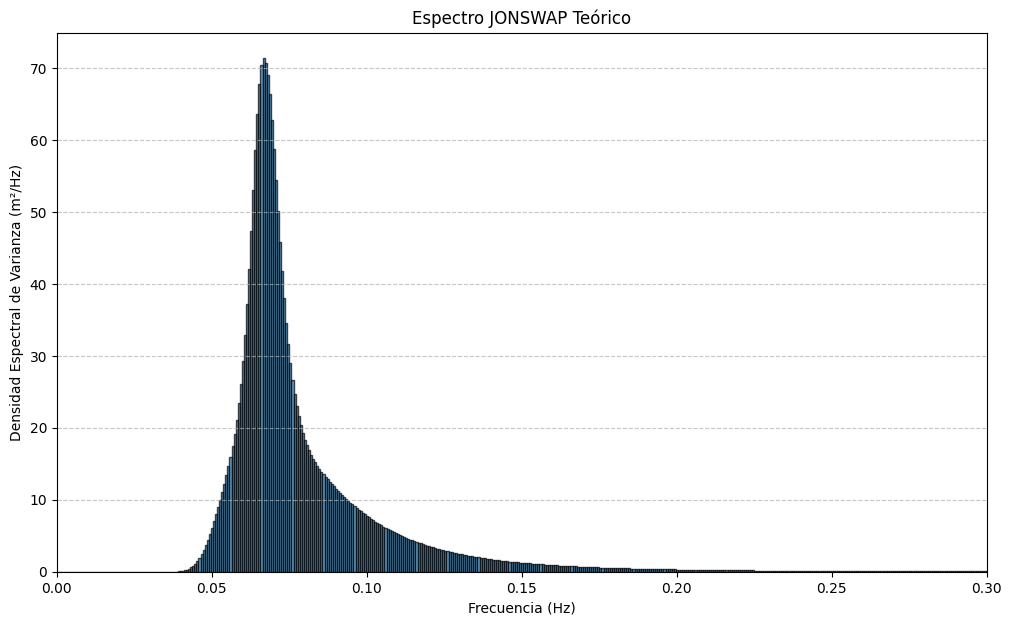

In [ ]:
def amplitud(array_S_f, delta_f):
  return np.sqrt(2*(array_S_f * delta_f))

print(delta_f)
print(f_nyquist)
array_f = np.arange(1e-15, f_nyquist + delta_f, delta_f)
print(array_f)
array_S_f = espectro_jonswap(array_f, f_p, alpha)
print(array_S_f)
array_amplitud = amplitud(array_S_f, delta_f)
print(array_amplitud)
array_tiempo = np.arange(1e-15, D + delta_t, delta_t)
print(array_tiempo)

plt.figure(figsize=(12, 7))

# Se usa plt.bar para crear el gráfico de barras.
# x: posiciones de las barras (las frecuencias)
# height: altura de las barras (los valores de densidad espectral)
# width: ancho de cada barra (el delta de frecuencia)
plt.bar(array_f, array_S_f, width=delta_f, edgecolor='black', alpha=0.7)

# Formato del gráfico
plt.title('Espectro JONSWAP Teórico')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad Espectral de Varianza (m²/Hz)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 0.3) # Limitar el eje X para enfocar en la zona con energía
plt.show()

Hacemos un array de etas con las misma cantidad de columnas que el tiempo, porque vamos a resover eta para cada t.

Hacemos un array de fases aleatorias uniformes entre 0 y 2pi, esto porque la diferentes componentes pueden empezar en cualquier momento del ciclo. Fijamos un seed para que a usted no le aparezca un array de fase aleatoria aleatorio cuando corra el código.

$$ \eta(t) = \sum_{i=1}^{N} a_i \cos(2\pi f_i t + \alpha_i) $$

eta(t) es una variable aleatoria ya que depende de fasea aleatoria para obtener su valor. Pero la amplitud a no lo es, porque el espectro jonswawp siempre darán los mismos valores cuando se utilizan las mismas constantes.

Convertimos los array que dependen del indice de frecuencia (amplitud, frecuencia, y fase) en una columna de 7500 filas (porque eran 7500 columnas) y el tiempo lo dejamos como estaba (en 15000 columnas). Numpy se encarga de todo al multiplicar.

Graficamos el eta por tiempo y se visualiza una muestra caótica producto de la fase aleatoria.


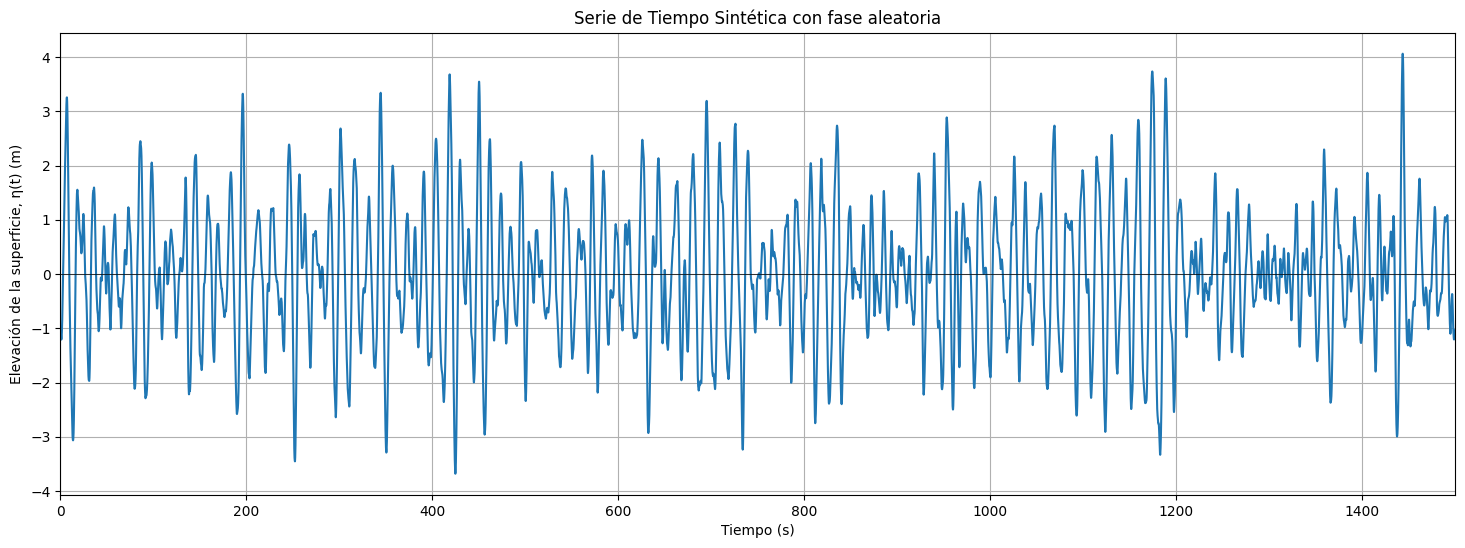

In [ ]:
array_eta = np.zeros_like(array_tiempo)
# fases aleatorias para generar ruido (Debería ser diferente cada vez que se corre el código, pero se fija una semilla)
#array_fase_aleatoria = np.linspace(0, 0, 7501)
np.random.seed(49)
array_fase_aleatoria = np.random.uniform(0, 2*np.pi, size=len(array_f))

#(matriz (N/2, N; 7500x15000): i(amplitud, frecuencia, fase aleatoria), j(tiempo))
terminos_coseno = array_amplitud[:, np.newaxis]*np.cos(2*np.pi*array_f[:, np.newaxis]*array_tiempo + array_fase_aleatoria[:, np.newaxis])
array_eta = np.sum(terminos_coseno, axis=0)

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(array_tiempo, array_eta)
ax.set_title('Serie de Tiempo Sintética con fase aleatoria')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Elevación de la superficie, η(t) (m)')
ax.set_xlim(0, D)
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5)
plt.show()

Definimos el método de down crossing. Primero restamos los promedios de eta para disminuir la variación de la fase aleatoria. Buscamos los indices donde para cada eta, su valor anterior sea mayor que 0 y (& = and) sea menos o igual a 0. y [0] por que la lista está dentro de otra lista como único elemento.

Hacemos un ciclo for para para calcular los valores mínimos y máximos para obtener la altura de cada onda. Agregamos todo a un array de alturas de onda.

Cálculamos la altura significativa y media cuadrática.

In [ ]:
def down_crossing(eta):
    eta = eta - np.mean(eta)
    indices = np.where((eta[:-1] > 0) & (eta[1:] <= 0))[0]
    alturas = []

    for i in range(len(indices)-1):
      cresta = np.max(eta[indices[i]:indices[i+1]])
      valle = np.min(eta[indices[i]:indices[i+1]])
      alturas.append(cresta - valle)
      alturas_array = np.array(alturas)
    return alturas_array

alturas_array = down_crossing(array_eta)

H_rms_experimental = np.sqrt(np.mean(alturas_array**2))
alturas_array_ordenadas = np.sort(alturas_array)[::-1]
tercio_olas = len(alturas_array_ordenadas)/3
alturas_tercio_array = alturas_array_ordenadas[:int(tercio_olas)]
H_s_experimental = np.mean(alturas_tercio_array)
print(H_s_experimental)
print(alturas_tercio_array)
print(np.trunc(tercio_olas))
print(alturas_array_ordenadas)
print(H_rms_experimental)


4.842883812904993
[7.05574453 6.93750077 6.11408203 6.03962366 5.90408378 5.78801213
 5.54341781 5.50933738 5.47426165 5.44585967 5.33792112 5.33026147
 5.32276774 5.29072691 5.28824259 5.12579809 5.07266337 5.06499069
 5.01077909 4.87477799 4.85555448 4.70707132 4.61871671 4.56389687
 4.56305805 4.54377267 4.52387794 4.44731863 4.41504373 4.34450096
 4.17906958 4.09090534 4.01026614 3.9470833  3.91704675 3.90336172
 3.80948864 3.80344455 3.67537634 3.65730198 3.64743387 3.6466781 ]
42.0
[7.05574453 6.93750077 6.11408203 6.03962366 5.90408378 5.78801213
 5.54341781 5.50933738 5.47426165 5.44585967 5.33792112 5.33026147
 5.32276774 5.29072691 5.28824259 5.12579809 5.07266337 5.06499069
 5.01077909 4.87477799 4.85555448 4.70707132 4.61871671 4.56389687
 4.56305805 4.54377267 4.52387794 4.44731863 4.41504373 4.34450096
 4.17906958 4.09090534 4.01026614 3.9470833  3.91704675 3.90336172
 3.80948864 3.80344455 3.67537634 3.65730198 3.64743387 3.6466781
 3.6427038  3.61241317 3.59634369 3.564

Creamos un array adimensional de Alturas, diviendo cada H del array por el H promedio. Tambien obtenemos el delta_H que es reciproco del H promedio que calculamos.

Ploteamos el array de alturas adimensionales y agregamos la opcion de density para que nos muestre la densidad por cada altura. Ploteamos la función de raylight.


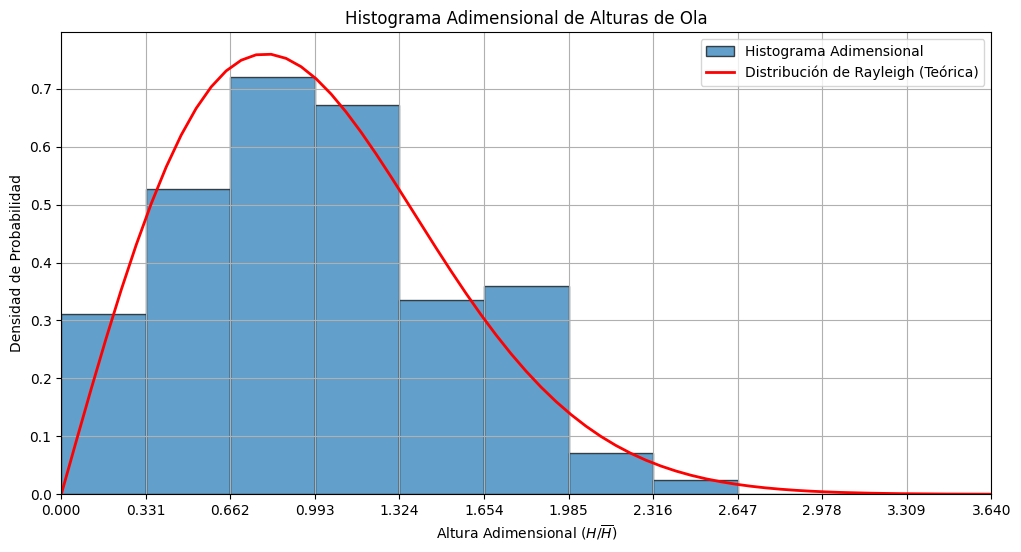

In [ ]:
H_promedio_experimental = np.mean(alturas_array)
delta_H = 1/H_promedio_experimental
alturas_adimensionales = alturas_array / H_promedio_experimental

plt.figure(figsize=(12, 6))
bin_array = np.arange(0, 12*delta_H, delta_H)
plt.hist(alturas_adimensionales, bins=bin_array, density=True, edgecolor='black', alpha=0.7, label='Histograma Adimensional')

x_teorico = np.linspace(0, 5*np.max(alturas_adimensionales), 200)
y_teorico = (np.pi/2) * x_teorico * np.exp(-(np.pi/4) * x_teorico**2)
plt.plot(x_teorico, y_teorico, 'r-', linewidth=2, label='Distribución de Rayleigh (Teórica)')

plt.title('Histograma Adimensional de Alturas de Ola')
plt.xlabel(r'Altura Adimensional ($H / \overline{H}$)')
plt.ylabel('Densidad de Probabilidad')
plt.xlim(0, np.max(bin_array))
plt.grid(True)
plt.xticks(bin_array)
plt.legend()
plt.show()


Creamos una tabla para comparar el error las alturas teóricas dadas y lo que obtuvimos por el análisis temporal. La diferencia es pequeña así que todo debería estar aplicado bien.

In [ ]:
diff_h_promedio = ((H_promedio_experimental - H_promedio) / H_promedio) * 100
diff_h_s = ((H_s_experimental - H_s) / H_s) * 100
diff_h_rms = ((H_rms_experimental - H_rms) / H_rms) * 100

data = {
    'Parámetro': ['H promedio (H)', 'H Significante (H_s)', 'H RMS'],
    'Valor Teórico (m)': [H_promedio, H_s, H_rms],
    'Valor Experimental (m)': [H_promedio_experimental, H_s_experimental, H_rms_experimental],
    'Diferencia (%)': [diff_h_promedio, diff_h_s, diff_h_rms]
}

df = pd.DataFrame(data)

df.set_index('Parámetro', inplace=True)

df_formateado = df.style.format({
    'Valor Teórico (m)': '{:.2f}',
    'Valor Experimental (m)': '{:.2f}',
    'Diferencia (%)': '{:+.2f}%'
})

df_formateado

,Valor Teórico (m),Valor Experimental (m),Diferencia (%)
Parámetro,,,
H promedio (H),3.10,3.02,-2.42%
H Significante (H_s),4.96,4.84,-2.28%
H RMS,3.50,3.41,-2.66%


Usamos la función welch para ensamblar los espectros. Su funcionamiento interno usa la transformada de fourier, pero simplifica todo el proceso, además permite colocar la cantidad de segmentos directamente, evitando dividir el array y promediandolo uno por uno, lo cual ahorra harto tiempo. Tambien se agrega la frecuencia de muestreo, por lo que se encarga del aliasing y la proporción. Lo hacemos para varios segmentos: 1, 5, 10, 30 y 100.

Hacemos un histograma para cada uno con barras de ancho de la duración del segmento. Añadimos el espectro de jonswap que obtuvimos en la parte anterior para poder visulaizar y calcular a través del coeficiente de bondad KGE que tanto se alinea al espectro original S_f.

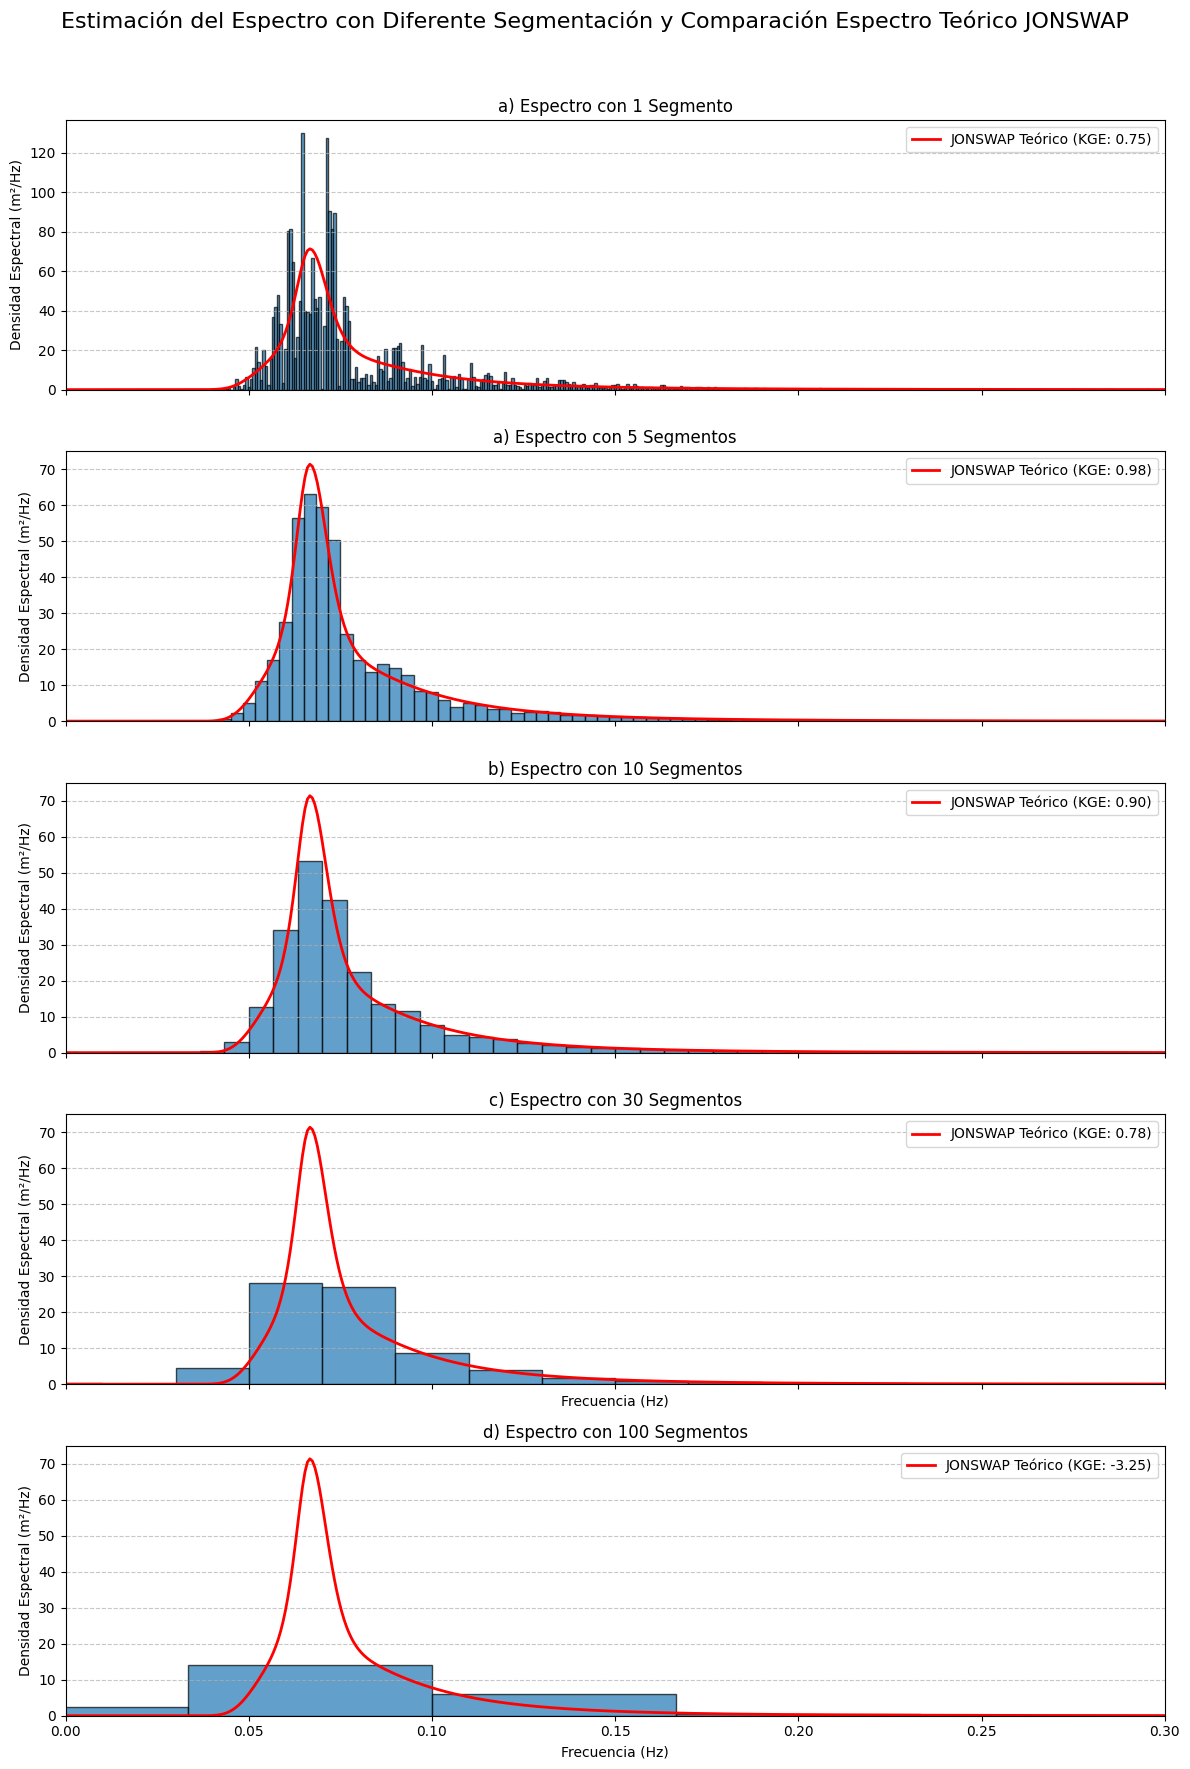

In [ ]:
def calcular_kge(simulado, observado):
    r = np.corrcoef(simulado, observado)[0, 1]
    beta = np.mean(simulado) / np.mean(observado)
    gamma = np.std(simulado) / np.std(observado)
    kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)

    return kge, r, beta, gamma

f_1, S_1 = signal.welch(array_eta, fs=f_s, nperseg=len(array_eta), noverlap=0)

segmento_5 = len(array_eta)/ 5
f_5, S_5 = signal.welch(array_eta, fs=f_s, nperseg=segmento_5)

segmento_10 = len(array_eta)/ 10
f_10, S_10 = signal.welch(array_eta, fs=f_s, nperseg=segmento_10)

segmento_30 = len(array_eta)/ 30
f_30, S_30 = signal.welch(array_eta, fs=f_s, nperseg=segmento_30)

segmento_100 = len(array_eta)/ 100
f_100, S_100 = signal.welch(array_eta, fs=f_s, nperseg=segmento_100)


fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)
fig.suptitle('Estimación del Espectro con Diferente Segmentación y Comparación Espectro Teórico JONSWAP', fontsize=16)

width_1 = 1/D #[f_min]
S_teorico_interpolado = np.interp(f_1, array_f, array_S_f)
kge, r, beta, gamma = calcular_kge(S_teorico_interpolado, S_1)
axes[0].bar(f_1, S_1, width=width_1, edgecolor='black', alpha=0.7)
axes[0].plot(array_f, array_S_f, 'r-', linewidth=2, label=f'JONSWAP Teórico (KGE: {kge:.2f})')
axes[0].set_title('a) Espectro con 1 Segmento')
axes[0].set_ylabel('Densidad Espectral (m²/Hz)')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axes[0].legend(loc='best')
axes[0].set_xlim(0, 0.3)

width_5 = 1/(D/5)
S_teorico_interpolado = np.interp(f_5, array_f, array_S_f)
kge, r, beta, gamma = calcular_kge(S_teorico_interpolado, S_5)
axes[1].bar(f_5, S_5, width=width_5, edgecolor='black', alpha=0.7)
axes[1].plot(array_f, array_S_f, 'r-', linewidth=2, label=f'JONSWAP Teórico (KGE: {kge:.2f})')
axes[1].set_title('a) Espectro con 5 Segmentos')
axes[1].set_ylabel('Densidad Espectral (m²/Hz)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axes[1].legend(loc='best')
axes[1].set_xlim(0, 0.3)

width_10 = 1/(D/10)
S_teorico_interpolado = np.interp(f_10, array_f, array_S_f)
kge, r, beta, gamma = calcular_kge(S_teorico_interpolado, S_10)
axes[2].bar(f_10, S_10, width=width_10, edgecolor='black', alpha=0.7)
axes[2].plot(array_f, array_S_f, 'r-', linewidth=2, label=f'JONSWAP Teórico (KGE: {kge:.2f})')
axes[2].set_title('b) Espectro con 10 Segmentos')
axes[2].set_ylabel('Densidad Espectral (m²/Hz)')
axes[2].legend(loc='best')
axes[2].grid(True, axis='y', linestyle='--', alpha=0.7)

width_30 = 1/(D/30)
S_teorico_interpolado = np.interp(f_30, array_f, array_S_f)
kge, r, beta, gamma = calcular_kge(S_teorico_interpolado, S_30)
axes[3].bar(f_30, S_30, width=width_30, edgecolor='black', alpha=0.7)
axes[3].plot(array_f, array_S_f, 'r-', linewidth=2, label=f'JONSWAP Teórico (KGE: {kge:.2f})')
axes[3].set_title('c) Espectro con 30 Segmentos')
axes[3].set_ylabel('Densidad Espectral (m²/Hz)')
axes[3].set_xlabel('Frecuencia (Hz)')
axes[3].legend(loc='best')
axes[3].grid(True, axis='y', linestyle='--', alpha=0.7)

width_100 = 1/(D/100) #Frecuencia peak 1/(Tp)
S_teorico_interpolado = np.interp(f_100, array_f, array_S_f)
kge, r, beta, gamma = calcular_kge(S_teorico_interpolado, S_100)
axes[4].bar(f_100, S_100, width=width_100, edgecolor='black', alpha=0.7)
axes[4].plot(array_f, array_S_f, 'r-', linewidth=2, label=f'JONSWAP Teórico (KGE: {kge:.2f})')
axes[4].set_title('d) Espectro con 100 Segmentos')
axes[4].set_ylabel('Densidad Espectral (m²/Hz)')
axes[4].set_xlabel('Frecuencia (Hz)')
axes[4].legend(loc='best')
axes[4].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**¿Puede a través de algún criterio encontrar un
número de segmento máximo a considerar?**
Si dejamos solo 1 segmento la resolución es muy alta, y se capta todo el ruido por la fase aleatoria que se agrega al calcular las amplitudes. A mayor cantidad de segmentos la resolución baja, pero se distinge cada vez la forma de la distribución original hasta que la resolución se reduce tanto que el histograma se achata mucho y no se puede extraer nada conclusivo de ahí (como en el de 100 segmentos): todas las frecuencias importantes se juntan con aquellas menos útiles. La frecuencia más importante debería ser la frecuencia peak, que tiene la mayor densidad espectral, o sea la mayor energía y altura, entonces la resolución debería ser lo suficientemente grande (delta_f < fp) para captar esa frecuencia, pero el gráfico de 30 segmentos tiene una resolución de aprox 3 veces más que que el periodo peak, y aún así no se parece a la forma original (kge = 0.78), el más parecido es el de 5 segmentos que tiene una resolución 20 veces mayor al periodo peak (kge=0.98), así que cuantas veces más tiene que ser el periodo peak debe depender de: La duración total del muestreo, la aleatoriedad de la fase que nos tocó, el tipo de espectro (en este caso JONSWAP). Lo innegable es que la frecuencia de resolución (delta_f) tiene que ser menor a la de la frecuencia peak.

Ahora se obtiene la frecuencia peak y el altura significativa (momento 0). Similar a lo que hicimos en la primera parte de tarea, donde tuvimos integrar la función, sin embargo, esta vez usamos el método de simpson de integración númerica (No usamos quad, porque ya no estamos integrando un función definida, como el espectro de jonswap) entre el array de varianza y frecuencia de 10 segmentos (De los que pedía la tarea, es el más alineado con el espectro original)

In [ ]:
fp_espectral = f_10[np.argmax(S_10)]
m0_espectral = simpson(S_10, f_10)
hm0_espectral = 4 * np.sqrt(m0_espectral)
#si asumimos raylight
hrms_espectral = (1.13/1.6)*hm0_espectral
h_promedio_espectral = hm0_espectral/1.6

print(fp_espectral)
print(1/fp_espectral)
print(m0_espectral)
print(hm0_espectral)
print(hrms_espectral)
print(h_promedio_espectral)

0.06666666666666667
15.0
1.5233010244163432
4.9368832668659985
3.4866738072241112
3.085552041791249


In [ ]:
data_final = {
    'Parámetro': ['H Significante', 'H RMS', 'H Promedio'],
    'Valor Teórico (m)': [H_s, H_rms, H_promedio],
    'Análisis Temporal (m)': [H_s_experimental, H_rms_experimental, H_promedio_experimental],
    'Análisis Espectral (m)': [hm0_espectral, hrms_espectral, h_promedio_espectral]
}

df = pd.DataFrame(data_final)
df.set_index('Parámetro', inplace=True)

df['Dif. Temporal vs Teórico (%)'] = ((df['Análisis Temporal (m)'] - df['Valor Teórico (m)']) / df['Valor Teórico (m)']) * 100
df['Dif. Espectral vs Teórico (%)'] = ((df['Análisis Espectral (m)'] - df['Valor Teórico (m)']) / df['Valor Teórico (m)']) * 100
df['Dif. Absoluta (m)'] = (df['Análisis Espectral (m)'] - df['Análisis Temporal (m)']).abs()

column_order = [
    'Valor Teórico (m)',
    'Análisis Temporal (m)',
    'Análisis Espectral (m)',
    'Dif. Absoluta (m)',
    'Dif. Temporal vs Teórico (%)',
    'Dif. Espectral vs Teórico (%)'
]
df = df[column_order]

df_formateado = df.style.format({
    'Valor Teórico (m)': '{:.3f}',
    'Análisis Temporal (m)': '{:.3f}',
    'Análisis Espectral (m)': '{:.3f}',
    'Dif. Absoluta (m)': '{:.3f}',
    'Dif. Temporal vs Teórico (%)': '{:+.2f}%',
    'Dif. Espectral vs Teórico (%)': '{:+.2f}%'
}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
)

display(df_formateado)

,Valor Teórico (m),Análisis Temporal (m),Análisis Espectral (m),Dif. Absoluta (m),Dif. Temporal vs Teórico (%),Dif. Espectral vs Teórico (%)
Parámetro,,,,,,
H Significante,4.956,4.843,4.937,0.094,-2.28%,-0.38%
H RMS,3.500,3.407,3.487,0.080,-2.66%,-0.38%
H Promedio,3.097,3.022,3.086,0.063,-2.42%,-0.38%


Se crea la tabla final con todos los valores obtenidos y la diferencia de ellos. El error es tan pequeño que se podría despreciar.

El error en el análisis temporal se debe a la fase aleatoria, el array que contiene estos valores se suporpone que con las amplitudes originales, por lo que el downcrossing tiene un porcentaje de error en captar la alturas de onda para su posterior analisis. Es un algoritmo simple que solo considera el cambio de punto positivo a otro negativo para considerar el inicio de un ciclo de onda.

El error del espectro es aún más bajo, al ser un método más sofisticado el problema de la variabilidad por las fases aleatorias está más contenido, ya que considera cada uno de los valores del eta_array, descomponiendo cada frecuencia existente para crear el espectro de energía. Por lo que la fuente error más pronunciada puede ser la selección del segmento más apropiado para capturar la distribución más representativa.